In [15]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Ngumimi\Downloads\data.csv', encoding='latin1')

df_shape = df.shape
print(df_shape)

column_names = df.columns
print(column_names)

# I think the columns 'StockCode', 'Quantity', 'InvoiceDate'
# and 'UnitPrice' are the most important for this analysis.
# This is because information like total profit, average sales and other sales analysis can be gotten from the columns

# One row in this dataset represents the information about a single entity (item) sold by the business. 

column_types = df.info()
#print(column_types) 
# InvoiceNo, StockCode, Description, CustomerID and InvoiceDate are text (String)
# Ouantity, UnitPrice, CustomerId are numbers (integer)
# Country is a category (String)

print(df.isnull().sum())


(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [16]:
print(df.isnull().sum())

df['Description'] = df['Description'].fillna('Unknown')

df['CustomerID'] = df.groupby('InvoiceNo')['CustomerID'].ffill().bfill()

print(df.isnull().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [17]:
df_duplicate = df.duplicated().sum()
print(df_duplicate)

df_cleaned = df.drop_duplicates(keep=False)
print(df_cleaned)

5268
       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0    

In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.columns)


Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')


In [19]:
# Percentage of total orders per country
country_percentages = (df['country'].value_counts() / df.shape[0]) * 100
print(country_percentages.head())

print("\nFrom the analysis, the United Kingdom has the highest total order (in percentage)")

country
United Kingdom    91.431956
Germany            1.752139
France             1.579047
EIRE               1.512431
Spain              0.467422
Name: count, dtype: float64

From the analysis, the United Kingdom has the highest total order (in percentage)


In [20]:
best_sellers = df.groupby('description')['quantity'].sum().sort_values(ascending=False)
print(best_sellers.head(5))

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53847
JUMBO BAG RED RETROSPOT              47363
ASSORTED COLOUR BIRD ORNAMENT        36381
POPCORN HOLDER                       36334
PACK OF 72 RETROSPOT CAKE CASES      36039
Name: quantity, dtype: int64


In [22]:
# individual purchase revenue
df['revenue'] = df['quantity'] * df['unitprice']

# Extract month if your date column is converted to datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df['month'] = df['invoicedate'].dt.month

# Revenue by Month
monthly_revenue = df.groupby('month')['revenue'].sum()
print("Monthly Revenue:\n", monthly_revenue)

# Month  with the highest revenue
best_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

# Month number with the lowest revenue
least_month = monthly_revenue.idxmin()
lowest_revenue = monthly_revenue.min()

print(f"The highest revenue was in Month {best_month} with ${highest_revenue:,.2f}\n")
print(f"The lowest revenue was in Month {least_month} with ${lowest_revenue:,.2f}\n")


average_order = df['revenue'].mean()
highest_order = df['revenue'].max()

print(f"\nThe average order value is: ${average_order:,.2f}\n")
print(f"The highest single order value is: ${highest_order:,.2f}")

Monthly Revenue:
 month
1      560000.260
2      498062.650
3      683267.080
4      493207.121
5      723333.510
6      691123.120
7      681300.111
8      682680.510
9     1019687.622
10    1070704.670
11    1461756.250
12    1182625.030
Name: revenue, dtype: float64
The highest revenue was in Month 11 with $1,461,756.25

The lowest revenue was in Month 4 with $493,207.12


The average order value is: $17.99

The highest single order value is: $168,469.60


In [23]:
cancelled_orders = df[df['quantity'] < 0]
print(f"Number of cancelled/returned orders: {len(cancelled_orders)}")



Number of cancelled/returned orders: 10624


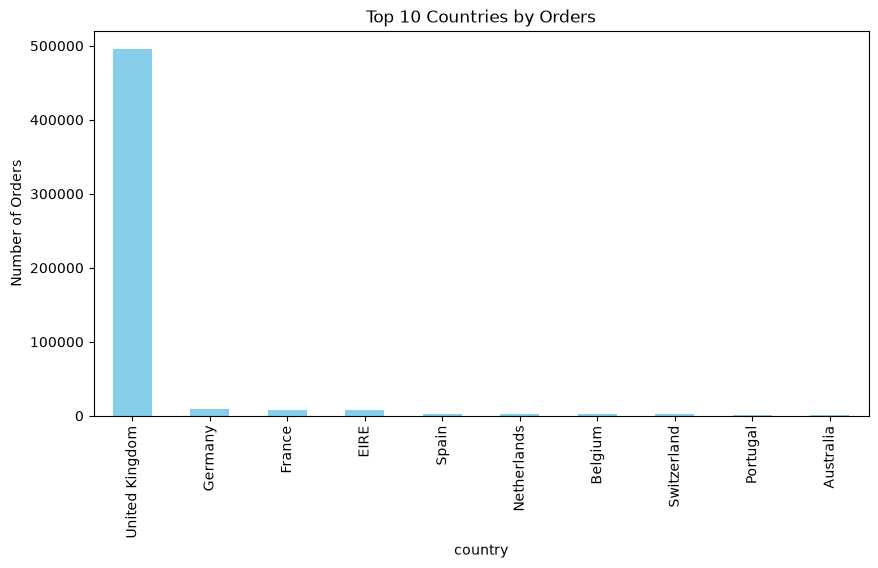


 The United Kingdom dominates 90% of the bar graph which indicates that the business depends heavy on sales to this region. 



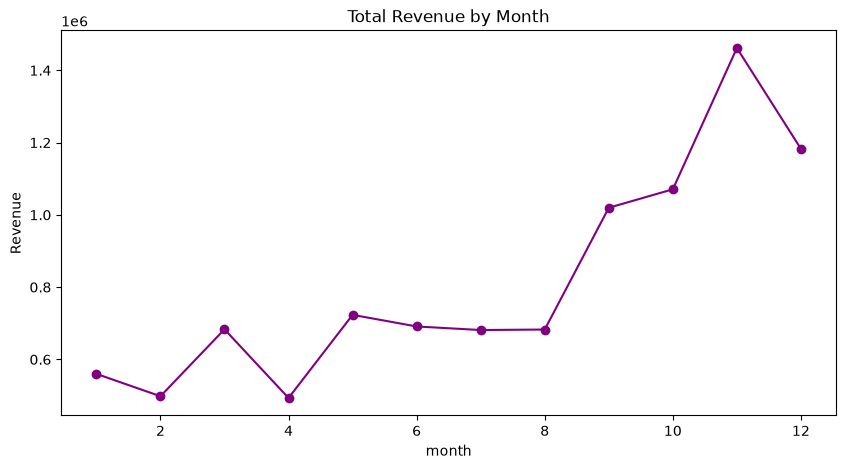


 The line chart indicates that the business experiences seasonal peaks during November/December while sales slow down in January. 



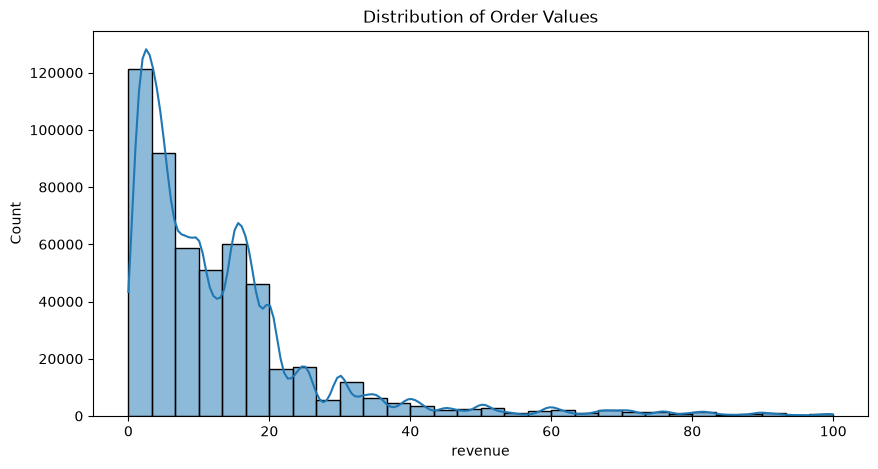


 A heavy right skew means the business relies heavily on high-volume, low-value small ticket transactions. 
 The customers are more likely to purchase large quantities of less expesive items.


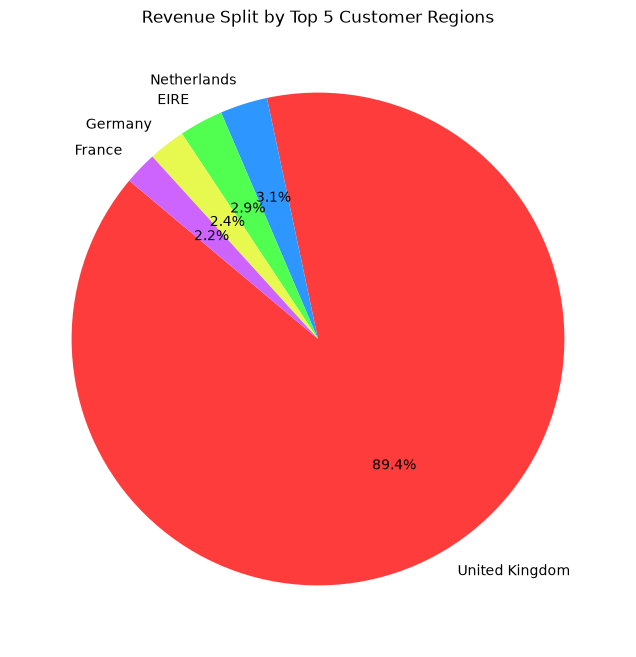


 It is evident from the pie chart that the market in the United Kingdom is thriving and generates the most revenue for the business.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sbn

plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Orders')
plt.ylabel('Number of Orders')
plt.show()
print("\n The United Kingdom dominates 90% of the bar graph which indicates that the business depends heavy on sales to this region. \n")

plt.figure(figsize=(10,5))
df.groupby('month')['revenue'].sum().plot(kind='line', marker='o', color='purple')
plt.title('Total Revenue by Month')
plt.ylabel('Revenue')
plt.show()
print("\n The line chart indicates that the business experiences seasonal peaks during November/December while sales slow down in January. \n")

plt.figure(figsize=(10,5))
sbn.histplot(df[(df['revenue'] > 0) & (df['revenue'] < 100)]['revenue'], bins=30, kde=True)
plt.title('Distribution of Order Values')
plt.show()
print("\n A heavy right skew means the business relies heavily on high-volume, low-value small ticket transactions. \n The customers are more likely to purchase large quantities of less expesive items.")

top_5_segments = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 8))

plt.pie(top_5_segments, 
        labels=top_5_segments.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=["#ff3c3c","#2e97ff","#50ff50","#e7f84e","#cd64fe"])

plt.title('Revenue Split by Top 5 Customer Regions')
plt.show()
print("\n It is evident from the pie chart that the market in the United Kingdom is thriving and generates the most revenue for the business.")


In [27]:
print("~~~~~~~~~~~~~~~~~~~~~~INSIGHTS~~~~~~~~~~~~~~~~~~~~~~")
print("Insight 1 -- The month of November generated the Highest Revenue with $1,461,756.25 while April generated the Lowest Revenue with $493,207.12 indicating a seasonal peak. \n")

print("Insight 2 -- The Business generated 89.4% of its revenue from through sales to its buyers in the United Kingdom. \n")

print("Insight 3 -- The average order value is $17.99 \n")

print("Insight 4 -- The highest single order value is $168,469.60 \n")

print("Insight 5 -- The quantity of cancelled or returned orders is 10,624")

print()

~~~~~~~~~~~~~~~~~~~~~~INSIGHTS~~~~~~~~~~~~~~~~~~~~~~
Insight 1 -- The month of November generated the Highest Revenue with $1,461,756.25 while April generated the Lowest Revenue with $493,207.12 indicating a seasonal peak. 

Insight 2 -- The Business generated 89.4% of its revenue from through sales to its buyers in the United Kingdom. 

Insight 3 -- The average order value is $17.99 

Insight 4 -- The highest single order value is $168,469.60 

Insight 5 -- The quantity of cancelled or returned orders is 10,624



In [26]:
print("~~~~~~~~~~~~~~~~~~~~~~ BUSINESS RECOMMENDATION ~~~~~~~~~~~~~~~~~~~~~~")
print("From the analysis, the business should invest in growing smaller markets especially during data proven seasonal peaks while maintaining the already established markets in a region like the UK. \n")

print("Based on the monthly sales trend, the business needs to run its biggest promotions during the months of November & December and prepare adequate products and staff to prevent being overwhelmed. \n")

print("Based on the analysis, the business should reduce stock levels or liquidate the bottom 5 underperforming products identified in the data to clear out warehouse carrying costs. \n")

print("Based on the analysis, the should run discount sales for low performing products especially in its secondary region of sales like France and Netherlands. \n")


~~~~~~~~~~~~~~~~~~~~~~ BUSINESS RECOMMENDATION ~~~~~~~~~~~~~~~~~~~~~~
From the analysis, the business should invest in growing smaller markets especially during data proven seasonal peaks while maintaining the already established markets in a region like the UK. 

Based on the monthly sales trend, the business needs to run its biggest promotions during the months of November & December and prepare adequate products and staff to prevent being overwhelmed. 

Based on the analysis, the business should reduce stock levels or liquidate the bottom 5 underperforming products identified in the data to clear out warehouse carrying costs. 

Based on the analysis, the should run discount sales for low performing products especially in its secondary region of sales like France and Netherlands. 



In [25]:
print("~~~~~~~~~~~~~~~~~~~~~~ FINAL RECOMMENDATION ~~~~~~~~~~~~~~~~~~~~~~ \n")

print("Launch promotional campaigns 30 days prior to November to capitalize on the historical seasonal demand spike.  \n")
print("Increase sales of the best selling products like WORLD WAR 2 GLIDERS ASSTD DESIGNS. \n")
print("Investigate why sales are lagging in secondary regions by performing adequate market research. \n")

~~~~~~~~~~~~~~~~~~~~~~ FINAL RECOMMENDATION ~~~~~~~~~~~~~~~~~~~~~~ 

Launch promotional campaigns 30 days prior to November to capitalize on the historical seasonal demand spike.  

Increase sales of the best selling products like WORLD WAR 2 GLIDERS ASSTD DESIGNS. 

Investigate why sales are lagging in secondary regions by performing adequate market research. 

